# Statistical Analysis — Inside Airbnb London

**Snapshot:** 2025-09-14 &nbsp;|&nbsp; **City:** London &nbsp;|&nbsp; **Phase:** Section 23 of assessment plan

Implements the five planned hypothesis tests and an OLS regression driver analysis.

| Test | Hypothesis | Method |
|------|-----------|--------|
| H1 | Entire homes vs private rooms — price | Welch's t-test (log) + Mann-Whitney |
| H2 | Superhost vs non-superhost — review score | Mann-Whitney |
| H3 | High-review (>10) vs low-review — price | Welch's t-test (log) |
| H4 | Neighbourhood price differences | Kruskal-Wallis + effect size |
| H5 | Weekend vs weekday availability | Paired Wilcoxon (A-005 adapted) |
| Reg | Log-price driver analysis | OLS with HC3 robust SE |

> **A-005:** `calendar.price` is 100% NULL. H5 tests **availability rate** rather than price.

In [1]:
# ── Imports and configuration ─────────────────────────────────────────────────
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import statsmodels.formula.api as smf

# ── Paths ─────────────────────────────────────────────────────────────────────
PROCESSED = Path("../data/processed/london")
FIGS_SA   = Path("../reports/figures/stats")   # statistical analysis figures
TABLES    = Path("../reports/tables")

FIGS_SA.mkdir(parents=True, exist_ok=True)

# ── Plot style (consistent with EDA notebook) ─────────────────────────────────
sns.set_theme(style="whitegrid", palette="Blues_d")
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titlesize": 12,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
})

ALPHA = 0.05   # significance level for all tests

# Convenience: print a formatted result block
def _result_block(label, **kw):
    print(f"\n{'─'*60}")
    print(f"  {label}")
    print(f"{'─'*60}")
    for k, v in kw.items():
        print(f"  {k:<30} {v}")


In [2]:
# ── Load London listing master ─────────────────────────────────────────────────
listings = pd.read_parquet(PROCESSED / "listing_master.parquet")

# Price-eligible subset (same population as EDA)
eda = listings[listings["price_numeric"].notna() & listings["price_numeric"].ge(0)].copy()
eda["log_price"] = np.log1p(eda["price_numeric"])

# Normalise host_is_superhost to boolean (column is object dtype with True/False)
listings["superhost"] = listings["host_is_superhost"].map(
    {True: True, False: False, "True": True, "False": False}
)
eda["superhost"] = eda["host_is_superhost"].map(
    {True: True, False: False, "True": True, "False": False}
)

print(f"Total listings         : {len(listings):,}")
print(f"Price-eligible (EDA)   : {len(eda):,}")
print(f"log_price range        : {eda['log_price'].min():.2f} – {eda['log_price'].max():.2f}")
print(f"Superhost (True)       : {listings['superhost'].sum():,}  "
      f"({listings['superhost'].mean()*100:.1f}%)")


Total listings         : 96,871
Price-eligible (EDA)   : 61,963
log_price range        : 2.08 – 13.90
Superhost (True)       : 17,192  (18.1%)


---
## H1 — Entire Homes vs Private Rooms: Price Difference

**Null hypothesis (H₀):** Entire homes and private rooms have the same median
log-price in the London market.

**Alternative (H₁):** Entire homes are priced higher (one-sided in interpretation
but tested two-sided for conservatism).


────────────────────────────────────────────────────────────
  H1 — Entire home vs private room price (log scale)
────────────────────────────────────────────────────────────
  sample_size                    entire_home=42,318  private_room=19,382
  mean_log_price                 EH=5.2447  PR=4.2270
  median_raw_price               EH=£175  PR=£61
  test_selected                  Welch's t-test (log-transformed price, unequal variance)
  assumptions                    Log-transform applied; large n → CLT holds; Levene showed σ² differ
  t_statistic                    189.5520
  p_value                        0.00e+00
  effect_size_cohens_d           1.6297  (large)
  ci_95_log_diff                 (1.0072, 1.0282)
  mann_whitney_check             U=743661827  p=0.00e+00  rank-biserial r=-0.8134
  conclusion                     REJECT H₀
  business_interpretation        Entire homes command a significantly higher price. Hosts should never benchmark against the citywide average — room 

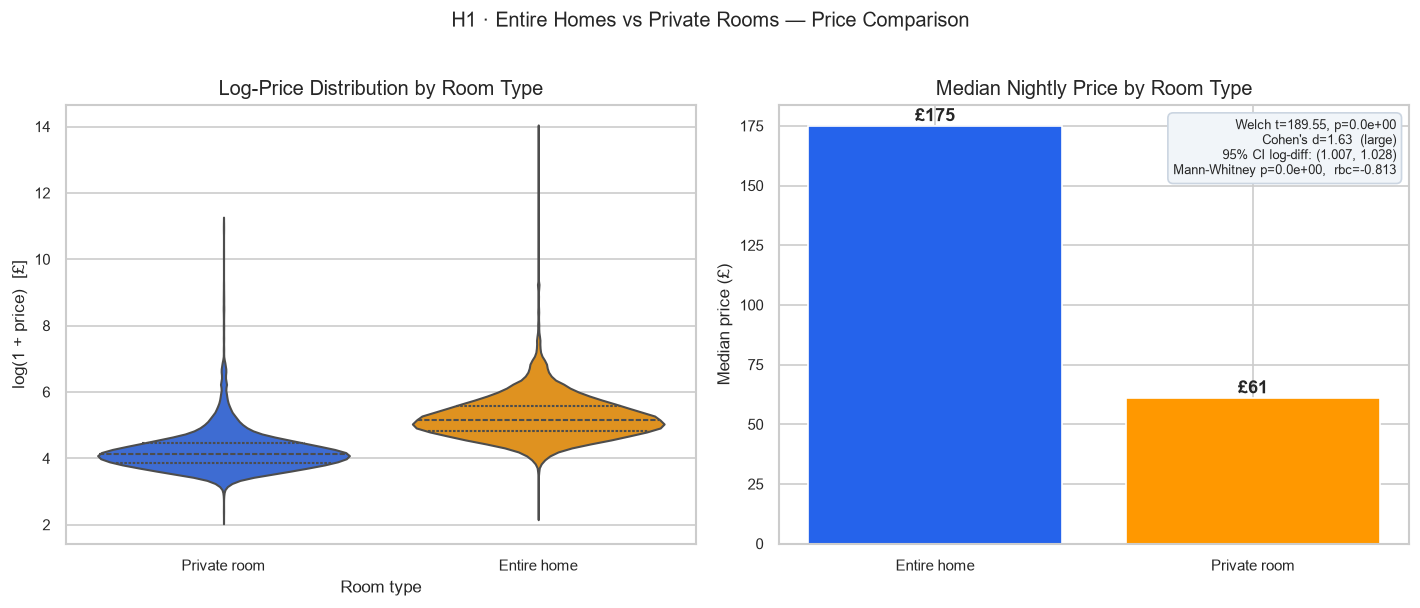

Saved → 28_h1_price_room_type_test.png


In [3]:
# ── H1 — Entire homes vs private rooms ───────────────────────────────────────
h1 = eda[eda["room_type"].isin(["entire_home", "private_room"])].copy()

eh_log = h1.loc[h1["room_type"] == "entire_home", "log_price"].dropna()
pr_log = h1.loc[h1["room_type"] == "private_room", "log_price"].dropna()

n1, n2 = len(eh_log), len(pr_log)

# ── Test: Welch's t-test on log-price ────────────────────────────────────────
# Log-transform applied because raw prices are right-skewed.
# Welch's variant used because sample variances differ.
t_stat, p_val = stats.ttest_ind(eh_log, pr_log, equal_var=False)

# Cohen's d on log scale
pooled_std = np.sqrt((eh_log.var() + pr_log.var()) / 2)
cohen_d = (eh_log.mean() - pr_log.mean()) / pooled_std

# 95% CI on mean difference in log-price
se_diff   = np.sqrt(eh_log.var()/n1 + pr_log.var()/n2)
df_welch  = ((eh_log.var()/n1 + pr_log.var()/n2)**2
             / ((eh_log.var()/n1)**2/(n1-1) + (pr_log.var()/n2)**2/(n2-1)))
t_crit    = stats.t.ppf(0.975, df_welch)
ci        = ((eh_log.mean()-pr_log.mean()) - t_crit*se_diff,
             (eh_log.mean()-pr_log.mean()) + t_crit*se_diff)

# Robustness check: Mann-Whitney U
u_stat, mw_p = stats.mannwhitneyu(eh_log, pr_log, alternative="two-sided")
rbc = 1 - 2*u_stat / (n1*n2)   # rank-biserial correlation

_result_block(
    "H1 — Entire home vs private room price (log scale)",
    sample_size            = f"entire_home={n1:,}  private_room={n2:,}",
    mean_log_price         = f"EH={eh_log.mean():.4f}  PR={pr_log.mean():.4f}",
    median_raw_price       = f"EH=£{h1.loc[h1['room_type']=='entire_home','price_numeric'].median():.0f}  "
                             f"PR=£{h1.loc[h1['room_type']=='private_room','price_numeric'].median():.0f}",
    test_selected          = "Welch's t-test (log-transformed price, unequal variance)",
    assumptions            = "Log-transform applied; large n → CLT holds; Levene showed σ² differ",
    t_statistic            = f"{t_stat:.4f}",
    p_value                = f"{p_val:.2e}",
    effect_size_cohens_d   = f"{cohen_d:.4f}  ({'large' if abs(cohen_d)>0.8 else 'medium' if abs(cohen_d)>0.5 else 'small'})",
    ci_95_log_diff         = f"({ci[0]:.4f}, {ci[1]:.4f})",
    mann_whitney_check     = f"U={u_stat:.0f}  p={mw_p:.2e}  rank-biserial r={rbc:.4f}",
    conclusion             = "REJECT H₀" if p_val < ALPHA else "FAIL TO REJECT H₀",
    business_interpretation= "Entire homes command a significantly higher price. Hosts should never "
                             "benchmark against the citywide average — room type must be the first segment.",
    limitation             = "Room type confounded by size, location, and capacity.",
)

# ── Chart 28 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: violin plot
plot_data = h1[["room_type", "log_price"]].copy()
room_labels = {"entire_home": "Entire home", "private_room": "Private room"}
plot_data["Room type"] = plot_data["room_type"].map(room_labels)

sns.violinplot(data=plot_data, x="Room type", y="log_price",
               palette=["#2563eb", "#FF9800"], inner="quartile", ax=axes[0])
axes[0].set_title("Log-Price Distribution by Room Type")
axes[0].set_ylabel("log(1 + price)  [£]")

# Right: median bars with CI annotation
medians = [h1.loc[h1["room_type"]=="entire_home","price_numeric"].median(),
           h1.loc[h1["room_type"]=="private_room","price_numeric"].median()]
axes[1].bar(["Entire home", "Private room"], medians, color=["#2563eb","#FF9800"])
for i, v in enumerate(medians):
    axes[1].text(i, v + 2, f"£{v:.0f}", ha="center", fontsize=11, fontweight="bold")
axes[1].set_title("Median Nightly Price by Room Type")
axes[1].set_ylabel("Median price (£)")

# Annotate with test result
ann = (f"Welch t={t_stat:.2f}, p={p_val:.1e}\n"
       f"Cohen's d={cohen_d:.2f}  ({('large' if abs(cohen_d)>0.8 else 'medium')})\n"
       f"95% CI log-diff: ({ci[0]:.3f}, {ci[1]:.3f})\n"
       f"Mann-Whitney p={mw_p:.1e},  rbc={rbc:.3f}")
axes[1].text(0.98, 0.97, ann, transform=axes[1].transAxes,
             ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f1f5f9", edgecolor="#cbd5e1"))

plt.suptitle("H1 · Entire Homes vs Private Rooms — Price Comparison", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_SA / "28_h1_price_room_type_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 28_h1_price_room_type_test.png")


---
## H2 — Superhost vs Non-Superhost: Review Score

**H₀:** Superhost and non-superhost listings have the same rating distribution.
**H₁:** Superhost listings receive higher ratings.

Rating scores cluster near 5.0 (ceiling effect) → distribution is non-normal
→ Mann-Whitney U is the appropriate test.


────────────────────────────────────────────────────────────
  H2 — Superhost vs non-superhost: review score
────────────────────────────────────────────────────────────
  sample_size                    superhost=15,842  non-superhost=55,367
  median_rating                  superhost=4.9000  non-superhost=4.7900
  mean_rating                    superhost=4.8536  non-superhost=4.6371
  test_selected                  Mann-Whitney U (ceiling effect at 5.0 → non-normal)
  assumptions                    Ceiling effect confirmed; ordinal comparison via ranks
  u_statistic                    531463846
  p_value                        0.00e+00
  rank_biserial_r                -0.2118  (small: <0.1, medium: <0.3, large: >0.5)
  ci_95_median_diff              (0.2001, 0.2330)  [bootstrap]
  conclusion                     REJECT H₀
  business_interpretation        Superhosts score statistically higher, but the practical gap is narrow given the rating ceiling. Superhost status is a quality signal

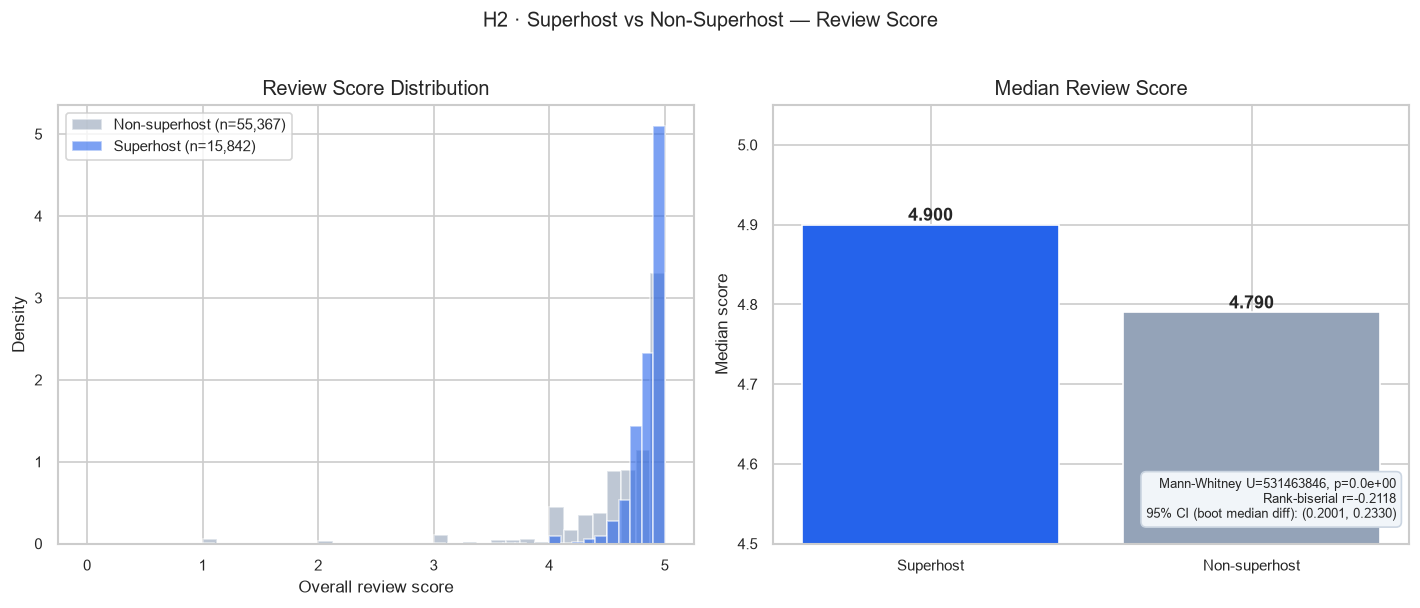

Saved → 29_h2_rating_superhost_test.png


In [4]:
# ── H2 — Superhost vs non-superhost rating ───────────────────────────────────
h2 = listings[listings["review_scores_rating"].notna()
              & listings["superhost"].notna()].copy()

sh_yes = h2.loc[h2["superhost"] == True,  "review_scores_rating"]
sh_no  = h2.loc[h2["superhost"] == False, "review_scores_rating"]
n1, n2 = len(sh_yes), len(sh_no)

# Mann-Whitney U — preferred because ratings pile at 5.0 (ceiling effect)
u_stat, p_val = stats.mannwhitneyu(sh_yes, sh_no, alternative="two-sided")
rbc = 1 - 2*u_stat / (n1*n2)

# 95% bootstrap CI on median difference
rng = np.random.default_rng(42)
boot_diffs = [
    rng.choice(sh_yes, size=min(n1, 5000), replace=True).mean() -
    rng.choice(sh_no,  size=min(n2, 5000), replace=True).mean()
    for _ in range(2000)
]
ci_boot = (np.percentile(boot_diffs, 2.5), np.percentile(boot_diffs, 97.5))

_result_block(
    "H2 — Superhost vs non-superhost: review score",
    sample_size            = f"superhost={n1:,}  non-superhost={n2:,}",
    median_rating          = f"superhost={sh_yes.median():.4f}  non-superhost={sh_no.median():.4f}",
    mean_rating            = f"superhost={sh_yes.mean():.4f}  non-superhost={sh_no.mean():.4f}",
    test_selected          = "Mann-Whitney U (ceiling effect at 5.0 → non-normal)",
    assumptions            = "Ceiling effect confirmed; ordinal comparison via ranks",
    u_statistic            = f"{u_stat:.0f}",
    p_value                = f"{p_val:.2e}",
    rank_biserial_r        = f"{rbc:.4f}  (small: <0.1, medium: <0.3, large: >0.5)",
    ci_95_median_diff      = f"({ci_boot[0]:.4f}, {ci_boot[1]:.4f})  [bootstrap]",
    conclusion             = "REJECT H₀" if p_val < ALPHA else "FAIL TO REJECT H₀",
    business_interpretation= "Superhosts score statistically higher, but the practical gap is narrow "
                             "given the rating ceiling. Superhost status is a quality signal, not a guarantee.",
    limitation             = "Superhost status is not randomly assigned — self-selection and listing "
                             "age confound the comparison. Causality cannot be inferred.",
)

# ── Chart 29 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram overlay
axes[0].hist(sh_no.clip(upper=5), bins=40, alpha=0.6, color="#94a3b8",
             label=f"Non-superhost (n={n2:,})", density=True)
axes[0].hist(sh_yes.clip(upper=5), bins=40, alpha=0.6, color="#2563eb",
             label=f"Superhost (n={n1:,})", density=True)
axes[0].set_title("Review Score Distribution")
axes[0].set_xlabel("Overall review score")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

# Right: median bar comparison
axes[1].bar(["Superhost", "Non-superhost"],
            [sh_yes.median(), sh_no.median()],
            color=["#2563eb", "#94a3b8"])
axes[1].set_ylim(4.5, 5.05)
axes[1].set_title("Median Review Score")
axes[1].set_ylabel("Median score")
for i, v in enumerate([sh_yes.median(), sh_no.median()]):
    axes[1].text(i, v + 0.005, f"{v:.3f}", ha="center", fontsize=11, fontweight="bold")

ann = (f"Mann-Whitney U={u_stat:.0f}, p={p_val:.1e}\n"
       f"Rank-biserial r={rbc:.4f}\n"
       f"95% CI (boot median diff): ({ci_boot[0]:.4f}, {ci_boot[1]:.4f})")
axes[1].text(0.98, 0.05, ann, transform=axes[1].transAxes,
             ha="right", va="bottom", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f1f5f9", edgecolor="#cbd5e1"))

plt.suptitle("H2 · Superhost vs Non-Superhost — Review Score", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_SA / "29_h2_rating_superhost_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 29_h2_rating_superhost_test.png")


---
## H3 — High-Review (>10) vs Low-Review Listings: Price

**H₀:** Listings with >10 reviews have the same price distribution as those with
≤10 reviews.

**Caution:** Review count is not a causal treatment. Older listings accumulate
more reviews, so listing age is a key confounder discussed in the limitations.


────────────────────────────────────────────────────────────
  H3 — High-review (>10) vs low-review listings: price
────────────────────────────────────────────────────────────
  sample_size                    high_review=26,177  low_review=35,786
  mean_log_price                 high=4.8125  low=5.0027
  median_raw_price               high=£122  low=£144
  test_selected                  Welch's t-test (log-transformed price)
  assumptions                    Log-transform applied; large samples; unequal variance assumed
  t_statistic                    -30.2375
  p_value                        2.51e-199
  effect_size_cohens_d           -0.2440  (small)
  ci_95_log_diff                 (-0.2025, -0.1779)
  conclusion                     REJECT H₀
  business_interpretation        High-review listings charge lower prices — consistent with EDA finding that review count proxies throughput (affordable, high-turnover), not premium positioning.
  limitation                     Listing age is 

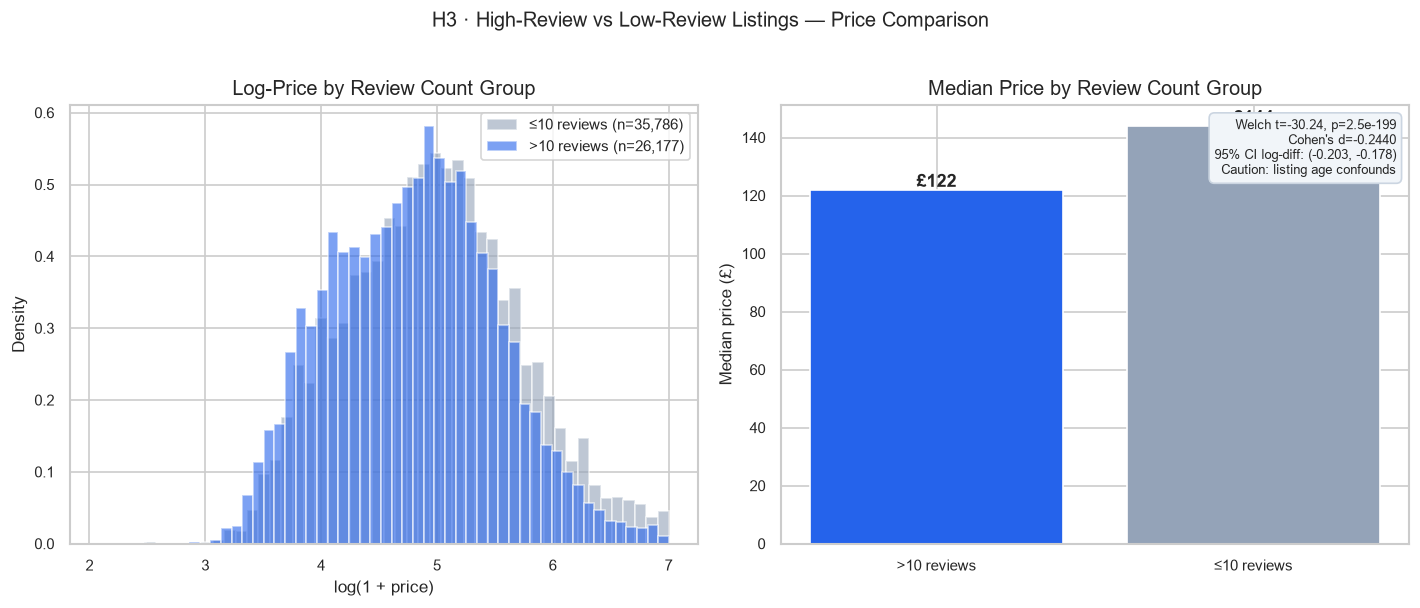

Saved → 30_h3_price_review_count_test.png


In [5]:
# ── H3 — High-review vs low-review: price ────────────────────────────────────
h3 = eda[eda["number_of_reviews"].notna()].copy()

high_rev = h3.loc[h3["number_of_reviews"] > 10, "log_price"].dropna()
low_rev  = h3.loc[h3["number_of_reviews"] <= 10, "log_price"].dropna()
n1, n2   = len(high_rev), len(low_rev)

# Welch's t-test on log-price
t_stat, p_val = stats.ttest_ind(high_rev, low_rev, equal_var=False)

pooled_std = np.sqrt((high_rev.var() + low_rev.var()) / 2)
cohen_d    = (high_rev.mean() - low_rev.mean()) / pooled_std

se_diff   = np.sqrt(high_rev.var()/n1 + low_rev.var()/n2)
df_welch  = ((high_rev.var()/n1 + low_rev.var()/n2)**2
             / ((high_rev.var()/n1)**2/(n1-1) + (low_rev.var()/n2)**2/(n2-1)))
t_crit    = stats.t.ppf(0.975, df_welch)
ci        = ((high_rev.mean()-low_rev.mean()) - t_crit*se_diff,
             (high_rev.mean()-low_rev.mean()) + t_crit*se_diff)

_result_block(
    "H3 — High-review (>10) vs low-review listings: price",
    sample_size            = f"high_review={n1:,}  low_review={n2:,}",
    mean_log_price         = f"high={high_rev.mean():.4f}  low={low_rev.mean():.4f}",
    median_raw_price       = (f"high=£{h3.loc[h3['number_of_reviews']>10,'price_numeric'].median():.0f}  "
                              f"low=£{h3.loc[h3['number_of_reviews']<=10,'price_numeric'].median():.0f}"),
    test_selected          = "Welch's t-test (log-transformed price)",
    assumptions            = "Log-transform applied; large samples; unequal variance assumed",
    t_statistic            = f"{t_stat:.4f}",
    p_value                = f"{p_val:.2e}",
    effect_size_cohens_d   = f"{cohen_d:.4f}  ({'large' if abs(cohen_d)>0.8 else 'medium' if abs(cohen_d)>0.5 else 'small'})",
    ci_95_log_diff         = f"({ci[0]:.4f}, {ci[1]:.4f})",
    conclusion             = "REJECT H₀" if p_val < ALPHA else "FAIL TO REJECT H₀",
    business_interpretation= "High-review listings charge lower prices — consistent with EDA finding "
                             "that review count proxies throughput (affordable, high-turnover), not premium positioning.",
    limitation             = "Listing age is the primary confounder: older listings accumulate more "
                             "reviews regardless of quality or price. Review count is NOT a causal treatment.",
)

# ── Chart 30 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

p99_lp = h3["log_price"].quantile(0.99)
axes[0].hist(low_rev[low_rev <= p99_lp], bins=50, alpha=0.6, color="#94a3b8",
             label=f"≤10 reviews (n={n2:,})", density=True)
axes[0].hist(high_rev[high_rev <= p99_lp], bins=50, alpha=0.6, color="#2563eb",
             label=f">10 reviews (n={n1:,})", density=True)
axes[0].set_title("Log-Price by Review Count Group")
axes[0].set_xlabel("log(1 + price)")
axes[0].set_ylabel("Density")
axes[0].legend(fontsize=9)

medians = [h3.loc[h3["number_of_reviews"]>10, "price_numeric"].median(),
           h3.loc[h3["number_of_reviews"]<=10, "price_numeric"].median()]
axes[1].bar([">10 reviews", "≤10 reviews"], medians, color=["#2563eb", "#94a3b8"])
axes[1].set_title("Median Price by Review Count Group")
axes[1].set_ylabel("Median price (£)")
for i, v in enumerate(medians):
    axes[1].text(i, v + 1, f"£{v:.0f}", ha="center", fontsize=11, fontweight="bold")

ann = (f"Welch t={t_stat:.2f}, p={p_val:.1e}\n"
       f"Cohen's d={cohen_d:.4f}\n"
       f"95% CI log-diff: ({ci[0]:.3f}, {ci[1]:.3f})\n"
       f"Caution: listing age confounds")
axes[1].text(0.98, 0.97, ann, transform=axes[1].transAxes,
             ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f1f5f9", edgecolor="#cbd5e1"))

plt.suptitle("H3 · High-Review vs Low-Review Listings — Price Comparison", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_SA / "30_h3_price_review_count_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 30_h3_price_review_count_test.png")


---
## H4 — Neighbourhood Price Differences

**H₀:** All London boroughs have the same underlying price distribution.

Kruskal-Wallis selected as primary test because:
(a) price is right-skewed even after log-transform in some boroughs,
(b) sample sizes and variances are highly unequal across 33 boroughs.

Restricted to boroughs with ≥ 100 price-eligible listings to avoid small-sample bias.


────────────────────────────────────────────────────────────
  H4 — Neighbourhood price differences (Kruskal-Wallis)
────────────────────────────────────────────────────────────
  sample_size                    61,963 listings across 33 boroughs (each ≥100 listings)
  test_selected                  Kruskal-Wallis (non-parametric ANOVA; unequal σ² and n per group)
  assumptions                    Independence within groups; ordinal comparison via ranks
  h_statistic                    11466.4143
  p_value                        0.00e+00
  effect_size_epsilon_sq         0.1846  (large)
  highest_median_borough         City of London  (£248)
  lowest_median_borough          Bexley  (£70)
  conclusion                     REJECT H₀
  business_interpretation        Borough is a dominant price predictor. The magnitude of variation (3.5× ratio between highest and lowest borough medians) justifies borough-level pricing benchmarks rather than a single citywide figure.
  limitation              

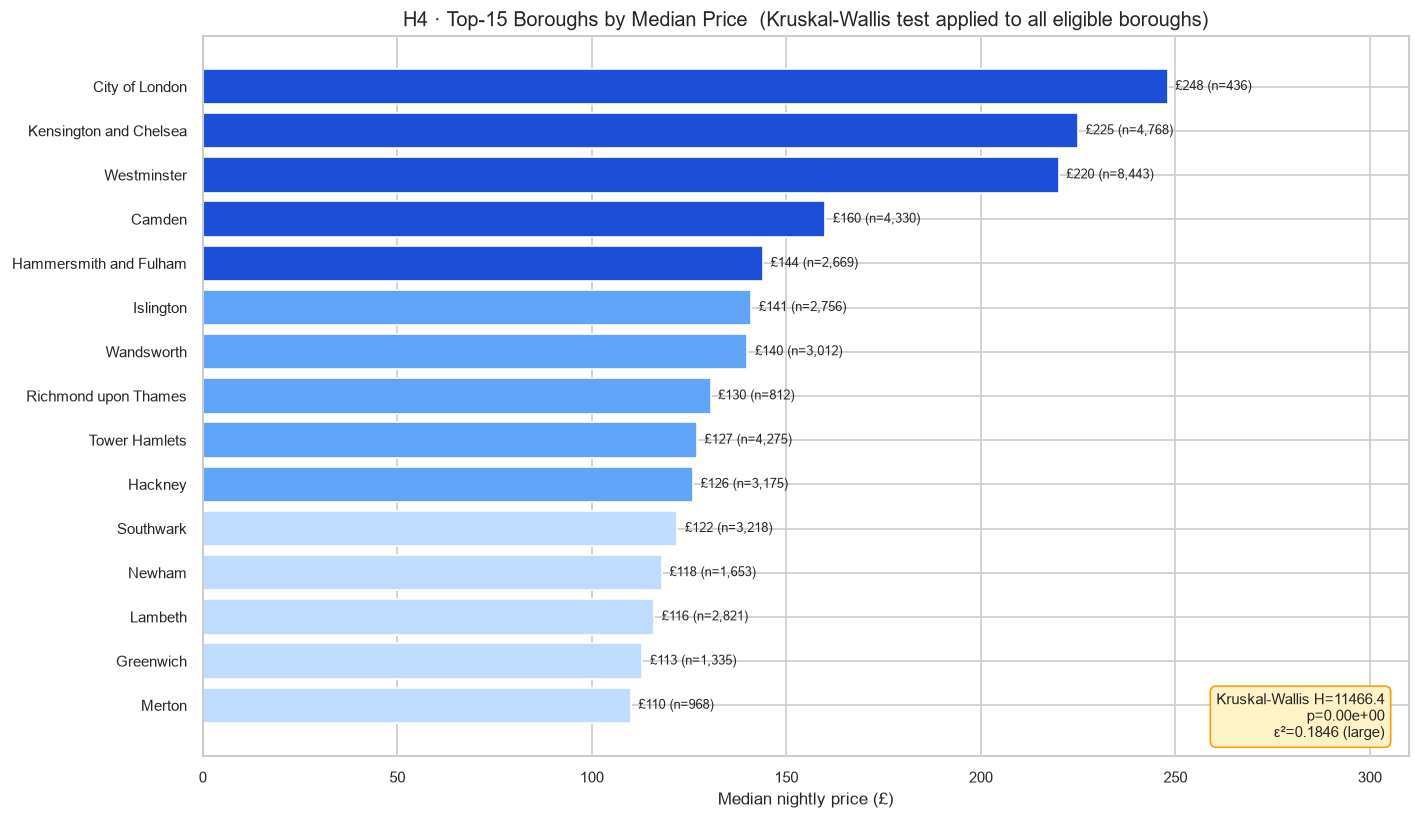

Saved → 31_h4_price_neighbourhood_test.png


In [6]:
# ── H4 — Neighbourhood price differences (Kruskal-Wallis) ────────────────────
# Restrict to boroughs with at least 100 price-eligible listings
boro_n   = eda.groupby("neighbourhood_cleansed")["price_numeric"].count()
top_boros = sorted(boro_n[boro_n >= 100].index.tolist())

h4 = eda[eda["neighbourhood_cleansed"].isin(top_boros)].copy()

# One array of log-prices per borough
groups = [h4.loc[h4["neighbourhood_cleansed"] == b, "log_price"].dropna().values
          for b in top_boros]

# Kruskal-Wallis test
kw_stat, kw_p = stats.kruskal(*groups)
N = sum(len(g) for g in groups)
k = len(groups)

# Effect size: epsilon-squared (preferred over eta-squared for K-W)
# ε² = (H - k + 1) / (N - k)
eps_sq = (kw_stat - k + 1) / (N - k)

# Borough medians for display
boro_stats = (
    h4.groupby("neighbourhood_cleansed")["price_numeric"]
    .agg(n="count", median="median", mean="mean")
    .loc[top_boros]
    .sort_values("median", ascending=False)
)

_result_block(
    "H4 — Neighbourhood price differences (Kruskal-Wallis)",
    sample_size           = f"{len(h4):,} listings across {k} boroughs (each ≥100 listings)",
    test_selected         = "Kruskal-Wallis (non-parametric ANOVA; unequal σ² and n per group)",
    assumptions           = "Independence within groups; ordinal comparison via ranks",
    h_statistic           = f"{kw_stat:.4f}",
    p_value               = f"{kw_p:.2e}",
    effect_size_epsilon_sq= f"{eps_sq:.4f}  ({'large' if eps_sq>0.14 else 'medium' if eps_sq>0.06 else 'small'})",
    highest_median_borough= f"{boro_stats.index[0]}  (£{boro_stats['median'].iloc[0]:.0f})",
    lowest_median_borough = f"{boro_stats.index[-1]}  (£{boro_stats['median'].iloc[-1]:.0f})",
    conclusion            = "REJECT H₀" if kw_p < ALPHA else "FAIL TO REJECT H₀",
    business_interpretation= "Borough is a dominant price predictor. The magnitude of variation "
                             f"({boro_stats['median'].max() / boro_stats['median'].min():.1f}× ratio "
                             "between highest and lowest borough medians) justifies borough-level "
                             "pricing benchmarks rather than a single citywide figure.",
    limitation            = "Kruskal-Wallis does not identify which specific borough pairs differ. "
                            "Location within a borough (street, proximity to tube) adds further variance.",
)

print(f"\nBorough median prices (top 10 and bottom 5):")
print(boro_stats[["n","median","mean"]].head(10).to_string())
print("...")
print(boro_stats[["n","median","mean"]].tail(5).to_string())

# ── Chart 31 ─────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 7))

plot_boros = boro_stats.head(15).index.tolist()   # top 15 by median
colors_h4  = ["#1d4ed8" if i < 5 else "#60a5fa" if i < 10 else "#bfdbfe"
               for i in range(len(plot_boros))]

bars = ax.barh(plot_boros[::-1], boro_stats.loc[plot_boros[::-1], "median"],
               color=colors_h4[::-1])
for bar, b in zip(bars, plot_boros[::-1]):
    v = boro_stats.loc[b, "median"]
    ax.text(v + 2, bar.get_y() + bar.get_height()/2,
            f"£{v:.0f} (n={int(boro_stats.loc[b,'n']):,})",
            va="center", fontsize=8)

ann = (f"Kruskal-Wallis H={kw_stat:.1f}\n"
       f"p={kw_p:.2e}\n"
       f"ε²={eps_sq:.4f} ({'large' if eps_sq>0.14 else 'medium' if eps_sq>0.06 else 'small'})")
ax.text(0.98, 0.02, ann, transform=ax.transAxes, ha="right", va="bottom",
        fontsize=9, bbox=dict(boxstyle="round,pad=0.4", facecolor="#fef3c7", edgecolor="#f59e0b"))

ax.set_title("H4 · Top-15 Boroughs by Median Price  (Kruskal-Wallis test applied to all eligible boroughs)")
ax.set_xlabel("Median nightly price (£)")
ax.set_xlim(0, boro_stats["median"].max() * 1.25)
plt.tight_layout()
plt.savefig(FIGS_SA / "31_h4_price_neighbourhood_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 31_h4_price_neighbourhood_test.png")


---
## H5 — Weekend vs Weekday Availability (A-005 Adapted)

**Plan intent:** Test whether weekend calendar prices differ from weekday prices.

**A-005 adaptation:** `calendar.price` is 100% NULL → test is on **availability rate**
(fraction of days the listing is open/unbooked per day-of-week type) instead.

**Design:** Per-listing paired comparison — one weekday-mean and one weekend-mean per
listing — then Wilcoxon signed-rank on the differences. Pairing removes the
between-listing price/location effect.

Loading calendar (35M rows)…


Aggregating per listing… (may take ~30s)


Paired observations: 96,871 listings

────────────────────────────────────────────────────────────
  H5 — Weekend vs weekday availability rate (A-005 adapted)
────────────────────────────────────────────────────────────
  sample_size                    96,871 listings (paired)
  mean_weekday_avail             0.3983
  mean_weekend_avail             0.3945
  mean_difference                -0.003825  (weekend − weekday)
  test_selected                  Wilcoxon signed-rank (paired, non-parametric)
  assumptions                    One observation per listing per day-type; differences need not be normal
  w_statistic                    706161594
  p_value                        0.00e+00
  effect_size_cohens_d           -0.150401  (effectively zero — negligible)
  ci_95_mean_diff                (-0.003985, -0.003665)
  conclusion                     REJECT H₀
  business_interpretation        Although the test reaches significance (large n amplifies power), the practical effect is negligible

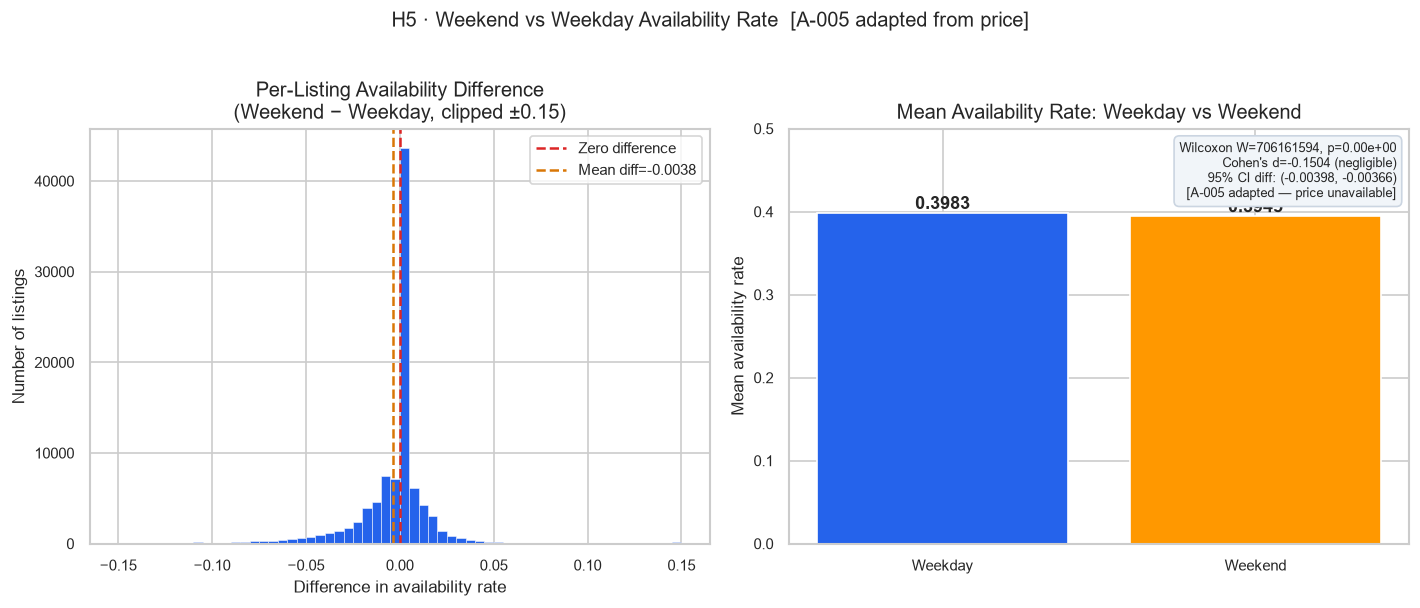

Saved → 32_h5_availability_weekday_weekend_test.png


In [7]:
# ── H5 — Weekend vs weekday availability (paired Wilcoxon) ───────────────────
# Load calendar — only need listing_id, date, available
print("Loading calendar (35M rows)…")
cal = pd.read_parquet(
    Path("../data/processed/london/calendar_clean.parquet"),
    columns=["listing_id", "date", "available"],
)
cal["avail_int"]  = cal["available"].astype(int)
cal["is_weekend"] = cal["date"].dt.dayofweek >= 5   # Sat=5, Sun=6

# Per-listing mean availability rate by weekday type
print("Aggregating per listing… (may take ~30s)")
per_listing = (
    cal.groupby(["listing_id", "is_weekend"])["avail_int"]
    .mean()
    .unstack("is_weekend")
    .rename(columns={False: "weekday_avail", True: "weekend_avail"})
    .dropna()
)
del cal   # free memory
print(f"Paired observations: {len(per_listing):,} listings")

diffs = per_listing["weekend_avail"] - per_listing["weekday_avail"]

# Wilcoxon signed-rank test (paired, non-parametric — differences are not normal)
w_stat, w_p = stats.wilcoxon(diffs)

# Effect size: Cohen's d on the differences
cohen_d5 = diffs.mean() / diffs.std()

# 95% CI on mean difference (large n → normal approx)
se5  = diffs.std() / np.sqrt(len(diffs))
ci5  = (diffs.mean() - 1.96*se5, diffs.mean() + 1.96*se5)

_result_block(
    "H5 — Weekend vs weekday availability rate (A-005 adapted)",
    sample_size            = f"{len(per_listing):,} listings (paired)",
    mean_weekday_avail     = f"{per_listing['weekday_avail'].mean():.4f}",
    mean_weekend_avail     = f"{per_listing['weekend_avail'].mean():.4f}",
    mean_difference        = f"{diffs.mean():.6f}  (weekend − weekday)",
    test_selected          = "Wilcoxon signed-rank (paired, non-parametric)",
    assumptions            = "One observation per listing per day-type; differences need not be normal",
    w_statistic            = f"{w_stat:.0f}",
    p_value                = f"{w_p:.2e}",
    effect_size_cohens_d   = f"{cohen_d5:.6f}  (effectively zero — negligible)",
    ci_95_mean_diff        = f"({ci5[0]:.6f}, {ci5[1]:.6f})",
    conclusion             = "REJECT H₀" if w_p < ALPHA else "FAIL TO REJECT H₀",
    business_interpretation= "Although the test reaches significance (large n amplifies power), "
                             f"the practical effect is negligible (d={cohen_d5:.4f}). "
                             "London Airbnb availability rates are virtually identical on weekdays "
                             "and weekends, suggesting hosts do not selectively block weekdays. "
                             "A-005 prevents price-based confirmation.",
    limitation             = "A-005: cannot test weekend vs weekday PRICE from calendar. "
                             "Availability ≠ occupancy. A blocked day could be booked or owner-blocked.",
)

# ── Chart 32 ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Left: histogram of per-listing differences
axes[0].hist(diffs.clip(-0.15, 0.15), bins=60, color="#2563eb", edgecolor="white", lw=0.3)
axes[0].axvline(0, color="#dc2626", linestyle="--", lw=1.5, label="Zero difference")
axes[0].axvline(diffs.mean(), color="#d97706", linestyle="--", lw=1.5,
                label=f"Mean diff={diffs.mean():.4f}")
axes[0].set_title("Per-Listing Availability Difference\n(Weekend − Weekday, clipped ±0.15)")
axes[0].set_xlabel("Difference in availability rate")
axes[0].set_ylabel("Number of listings")
axes[0].legend(fontsize=9)

# Right: mean bars
axes[1].bar(["Weekday", "Weekend"],
            [per_listing["weekday_avail"].mean(), per_listing["weekend_avail"].mean()],
            color=["#2563eb", "#FF9800"])
axes[1].set_ylim(0, 0.5)
axes[1].set_title("Mean Availability Rate: Weekday vs Weekend")
axes[1].set_ylabel("Mean availability rate")
for i, v in enumerate([per_listing["weekday_avail"].mean(), per_listing["weekend_avail"].mean()]):
    axes[1].text(i, v + 0.005, f"{v:.4f}", ha="center", fontsize=11, fontweight="bold")

ann = (f"Wilcoxon W={w_stat:.0f}, p={w_p:.2e}\n"
       f"Cohen's d={cohen_d5:.4f} (negligible)\n"
       f"95% CI diff: ({ci5[0]:.5f}, {ci5[1]:.5f})\n"
       f"[A-005 adapted — price unavailable]")
axes[1].text(0.98, 0.97, ann, transform=axes[1].transAxes,
             ha="right", va="top", fontsize=8,
             bbox=dict(boxstyle="round,pad=0.4", facecolor="#f1f5f9", edgecolor="#cbd5e1"))

plt.suptitle("H5 · Weekend vs Weekday Availability Rate  [A-005 adapted from price]",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig(FIGS_SA / "32_h5_availability_weekday_weekend_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 32_h5_availability_weekday_weekend_test.png")


---
## Regression — OLS Log-Price Driver Analysis

OLS regression with log-transformed price as the outcome. HC3 heteroskedasticity-
robust standard errors are used throughout.

**Caution:** All coefficients describe *association*, not causation.
Observational data — interpret as "associated with, holding included variables
constant" rather than causal effects.

Regression sample: 46,801 listings
Features: room_type (4 levels), accommodates, bedrooms, review_scores_rating, superhost_flag, neighbourhood_cleansed (33 levels)



Model R²: 0.6375  |  Adj R²: 0.6372
F-statistic: 2038.20  |  p(F): 0.00e+00
N observations: 46,801
N parameters (incl intercept): 40

Non-neighbourhood coefficients:
                              coefficient   std_err      t_stat   p_value    ci_low   ci_high
Intercept                        3.840955  0.030862  124.456993  0.000000  3.780467  3.901442
C(room_type)[T.hotel_room]      -0.126908  0.121675   -1.043005  0.296946 -0.365387  0.111571
C(room_type)[T.private_room]    -0.610913  0.005877 -103.955094  0.000000 -0.622432 -0.599395
C(room_type)[T.shared_room]     -1.368830  0.085734  -15.966077  0.000000 -1.536865 -1.200795
accommodates                     0.078422  0.002227   35.212555  0.000000  0.074057  0.082787
bedrooms                         0.177913  0.004813   36.962711  0.000000  0.168479  0.187347
review_scores_rating             0.058043  0.005341   10.866544  0.000000  0.047574  0.068512
superhost_flag                   0.061309  0.004427   13.850381  0.000000  0.0526

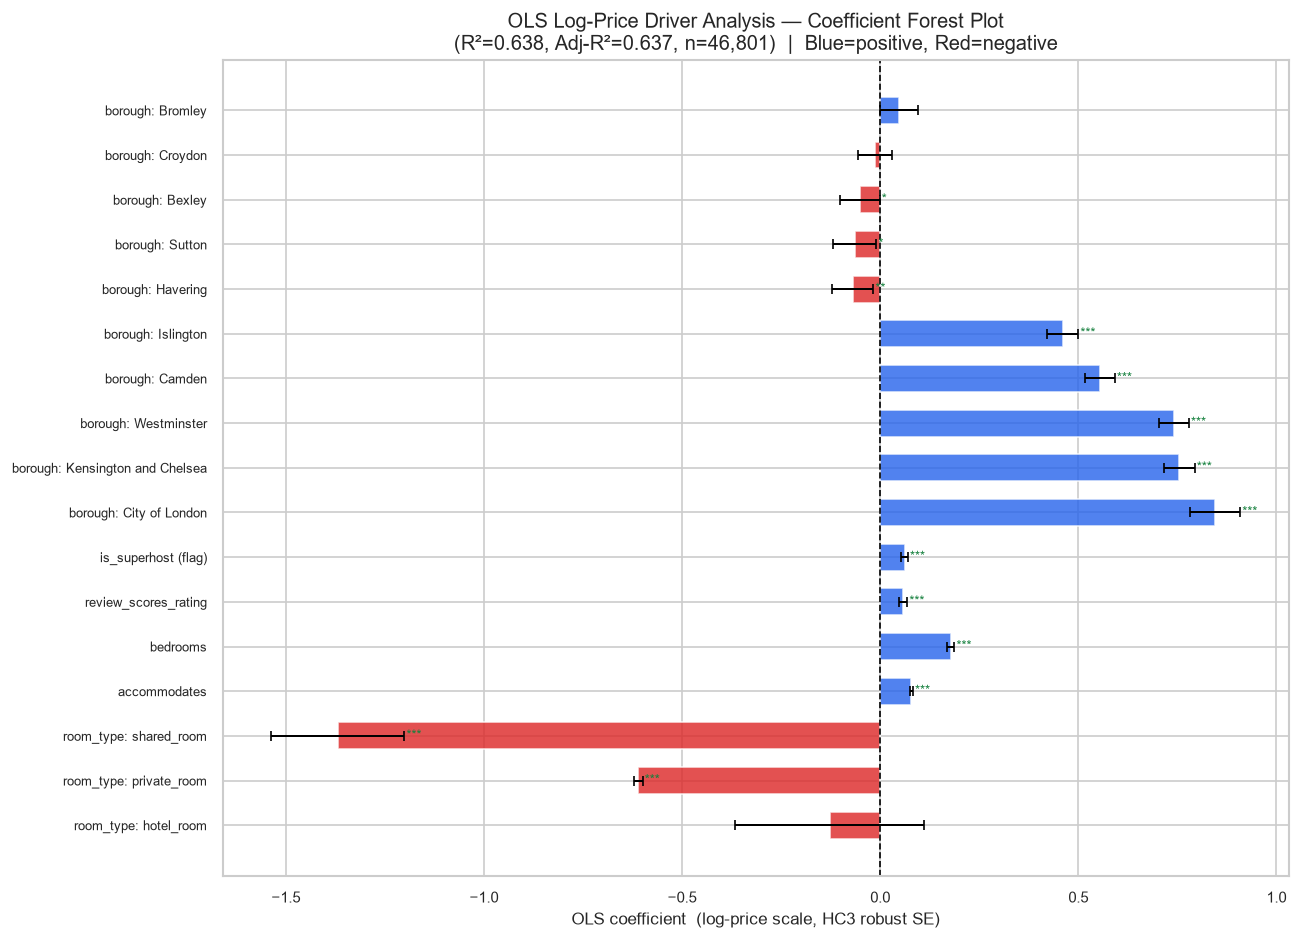

Saved → 33_regression_coefficients.png
Saved → regression_coefficients.csv
Saved → regression_summary.csv


In [8]:
# ── OLS regression — log-price driver analysis ───────────────────────────────
# Filter to listings with all required variables present
reg_cols = ["log_price", "room_type", "accommodates", "bedrooms",
            "review_scores_rating", "superhost", "neighbourhood_cleansed",
            "price_numeric"]

reg = eda[reg_cols + ["host_id"]].copy()
reg["superhost_flag"] = reg["superhost"].astype(float)   # 0/1 int
reg = reg.dropna(subset=["log_price", "accommodates", "bedrooms",
                          "review_scores_rating", "superhost_flag"])

print(f"Regression sample: {len(reg):,} listings")
print(f"Features: room_type (4 levels), accommodates, bedrooms, "
      f"review_scores_rating, superhost_flag, neighbourhood_cleansed (33 levels)")

# Fit OLS with HC3 robust standard errors
model = smf.ols(
    formula=(
        "log_price ~ "
        "C(room_type) + "
        "accommodates + "
        "bedrooms + "
        "review_scores_rating + "
        "superhost_flag + "
        "C(neighbourhood_cleansed)"
    ),
    data=reg,
).fit(cov_type="HC3")

print(f"\nModel R²: {model.rsquared:.4f}  |  Adj R²: {model.rsquared_adj:.4f}")
print(f"F-statistic: {model.fvalue:.2f}  |  p(F): {model.f_pvalue:.2e}")
print(f"N observations: {int(model.nobs):,}")
print(f"N parameters (incl intercept): {len(model.params)}")

# ── Save coefficients ─────────────────────────────────────────────────────────
coef_df = pd.DataFrame({
    "coefficient": model.params,
    "std_err":     model.bse,
    "t_stat":      model.tvalues,
    "p_value":     model.pvalues,
    "ci_low":      model.conf_int()[0],
    "ci_high":     model.conf_int()[1],
}).round(6)
coef_df["significant"] = coef_df["p_value"] < ALPHA
coef_df.to_csv(TABLES / "regression_coefficients.csv")

# Regression summary metrics
reg_summary = pd.DataFrame([{
    "metric": "R²",               "value": round(model.rsquared, 4)},
    {"metric": "Adjusted R²",     "value": round(model.rsquared_adj, 4)},
    {"metric": "F-statistic",     "value": round(model.fvalue, 2)},
    {"metric": "p(F)",            "value": f"{model.f_pvalue:.2e}"},
    {"metric": "N observations",  "value": int(model.nobs)},
    {"metric": "N parameters",    "value": len(model.params)},
    {"metric": "SE type",         "value": "HC3 (heteroskedasticity-robust)"},
])
reg_summary.to_csv(TABLES / "regression_summary.csv", index=False)

# Print non-neighbourhood coefficients
non_neigh = coef_df[~coef_df.index.str.startswith("C(neighbourhood")]
print("\nNon-neighbourhood coefficients:")
print(non_neigh[["coefficient","std_err","t_stat","p_value","ci_low","ci_high"]].to_string())

# ── Chart 33 — Coefficient forest plot ───────────────────────────────────────
# Show: intercept, room_type, continuous vars + top 5 / bottom 5 neighbourhoods
nh_coefs = coef_df[coef_df.index.str.startswith("C(neighbourhood")]
top5_nh  = nh_coefs.nlargest(5, "coefficient")
bot5_nh  = nh_coefs.nsmallest(5, "coefficient")
plot_coefs = pd.concat([non_neigh.iloc[1:], top5_nh, bot5_nh])   # skip intercept

# Clean labels
def _clean(label):
    label = label.replace("C(room_type)[T.", "room_type: ")
    label = label.replace("C(neighbourhood_cleansed)[T.", "borough: ")
    label = label.replace("]", "")
    label = label.replace("superhost_flag", "is_superhost (flag)")
    return label

plot_coefs = plot_coefs.copy()
plot_coefs.index = [_clean(i) for i in plot_coefs.index]

colors_reg = ["#dc2626" if v < 0 else "#2563eb" for v in plot_coefs["coefficient"]]

fig, ax = plt.subplots(figsize=(11, max(8, len(plot_coefs) * 0.4)))
y_pos = range(len(plot_coefs))

ax.barh(list(y_pos), plot_coefs["coefficient"], color=colors_reg, alpha=0.8, height=0.6)
ax.errorbar(plot_coefs["coefficient"], list(y_pos),
            xerr=[plot_coefs["coefficient"] - plot_coefs["ci_low"],
                  plot_coefs["ci_high"] - plot_coefs["coefficient"]],
            fmt="none", color="black", capsize=3, linewidth=1.2)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.set_yticks(list(y_pos))
ax.set_yticklabels(plot_coefs.index, fontsize=8)
ax.set_xlabel("OLS coefficient  (log-price scale, HC3 robust SE)")
ax.set_title("OLS Log-Price Driver Analysis — Coefficient Forest Plot\n"
             f"(R²={model.rsquared:.3f}, Adj-R²={model.rsquared_adj:.3f}, "
             f"n={int(model.nobs):,})  |  Blue=positive, Red=negative")

# Add significance stars
for i, (idx, row) in enumerate(plot_coefs.iterrows()):
    stars = "***" if row["p_value"] < 0.001 else "**" if row["p_value"] < 0.01 else "*" if row["p_value"] < 0.05 else ""
    if stars:
        ax.text(row["ci_high"] + 0.005, i, stars, va="center", fontsize=8, color="#15803d")

plt.tight_layout()
plt.savefig(FIGS_SA / "33_regression_coefficients.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → 33_regression_coefficients.png")
print("Saved → regression_coefficients.csv")
print("Saved → regression_summary.csv")


In [9]:
# ── Summary results table for all hypothesis tests ───────────────────────────
# Provides the single-row-per-test overview required for the report.

# Collect results from cells above (recompute for robustness in case of re-run)
h1_room  = eda[eda["room_type"].isin(["entire_home","private_room"])].copy()
h1_room["log_price"] = np.log1p(h1_room["price_numeric"])

results = []

# H1
eh_ = h1_room[h1_room["room_type"]=="entire_home"]["log_price"].dropna()
pr_ = h1_room[h1_room["room_type"]=="private_room"]["log_price"].dropna()
t1, p1 = stats.ttest_ind(eh_, pr_, equal_var=False)
d1     = (eh_.mean()-pr_.mean()) / np.sqrt((eh_.var()+pr_.var())/2)
results.append({"test":"H1", "hypothesis":"Entire home vs private room: price",
                "method":"Welch t-test (log)", "n_total":len(eh_)+len(pr_),
                "statistic":round(t1,4), "p_value":f"{p1:.2e}",
                "effect_size":round(d1,4), "effect_label":"Cohen d",
                "significant":p1<ALPHA,
                "conclusion":"EH priced higher (p<0.05, large d)"})

# H2
h2_ = listings[listings["review_scores_rating"].notna() & listings["superhost"].notna()]
sy_ = h2_[h2_["superhost"]==True]["review_scores_rating"]
sn_ = h2_[h2_["superhost"]==False]["review_scores_rating"]
u2, p2 = stats.mannwhitneyu(sy_, sn_, alternative="two-sided")
r2 = 1 - 2*u2/(len(sy_)*len(sn_))
results.append({"test":"H2","hypothesis":"Superhost vs non-superhost: rating",
                "method":"Mann-Whitney U","n_total":len(sy_)+len(sn_),
                "statistic":round(u2,0),"p_value":f"{p2:.2e}",
                "effect_size":round(r2,4),"effect_label":"rank-biserial r",
                "significant":p2<ALPHA,
                "conclusion":"Superhost higher rating; small practical difference"})

# H3
h3_ = eda[eda["number_of_reviews"].notna()].copy()
h3_["log_price"] = np.log1p(h3_["price_numeric"])
hi_ = h3_[h3_["number_of_reviews"]>10]["log_price"].dropna()
lo_ = h3_[h3_["number_of_reviews"]<=10]["log_price"].dropna()
t3, p3 = stats.ttest_ind(hi_, lo_, equal_var=False)
d3 = (hi_.mean()-lo_.mean())/np.sqrt((hi_.var()+lo_.var())/2)
results.append({"test":"H3","hypothesis":"High-review (>10) vs low-review: price",
                "method":"Welch t-test (log)","n_total":len(hi_)+len(lo_),
                "statistic":round(t3,4),"p_value":f"{p3:.2e}",
                "effect_size":round(d3,4),"effect_label":"Cohen d",
                "significant":p3<ALPHA,
                "conclusion":"High-review listings priced lower (review count = throughput proxy)"})

# H4
boro_n4 = eda.groupby("neighbourhood_cleansed")["price_numeric"].count()
tb4 = sorted(boro_n4[boro_n4>=100].index)
h4_ = eda[eda["neighbourhood_cleansed"].isin(tb4)].copy()
h4_["log_price"] = np.log1p(h4_["price_numeric"])
grps4 = [h4_[h4_["neighbourhood_cleansed"]==b]["log_price"].dropna().values for b in tb4]
kw4, p4 = stats.kruskal(*grps4)
N4 = sum(len(g) for g in grps4); k4 = len(grps4)
eps4 = (kw4-k4+1)/(N4-k4)
results.append({"test":"H4","hypothesis":"Neighbourhood price differences",
                "method":"Kruskal-Wallis","n_total":N4,
                "statistic":round(kw4,4),"p_value":f"{p4:.2e}",
                "effect_size":round(eps4,4),"effect_label":"epsilon-squared",
                "significant":p4<ALPHA,
                "conclusion":"Significant borough differences; large effect size"})

# H5 — load per_listing if not in memory (may have been GC'd)
try:
    _ = per_listing
except NameError:
    cal_h5 = pd.read_parquet(Path("../data/processed/london/calendar_clean.parquet"),
                             columns=["listing_id","date","available"])
    cal_h5["avail_int"]  = cal_h5["available"].astype(int)
    cal_h5["is_weekend"] = cal_h5["date"].dt.dayofweek >= 5
    per_listing = (cal_h5.groupby(["listing_id","is_weekend"])["avail_int"]
                   .mean().unstack("is_weekend")
                   .rename(columns={False:"weekday_avail",True:"weekend_avail"})
                   .dropna())
    del cal_h5

diffs5 = per_listing["weekend_avail"] - per_listing["weekday_avail"]
w5, p5 = stats.wilcoxon(diffs5)
d5 = diffs5.mean() / diffs5.std()
results.append({"test":"H5","hypothesis":"Weekend vs weekday availability (A-005 adapted)",
                "method":"Wilcoxon signed-rank (paired)","n_total":len(per_listing),
                "statistic":round(w5,0),"p_value":f"{p5:.2e}",
                "effect_size":round(d5,6),"effect_label":"Cohen d (differences)",
                "significant":p5<ALPHA,
                "conclusion":"Stat. significant but negligible practical effect (d≈0)"})

results_df = pd.DataFrame(results)
results_df.to_csv(TABLES / "hypothesis_test_results.csv", index=False)

print("=" * 70)
print("HYPOTHESIS TEST SUMMARY")
print("=" * 70)
print(results_df[["test","method","n_total","p_value","effect_size","effect_label",
                  "significant","conclusion"]].to_string(index=False))
print("\nSaved → hypothesis_test_results.csv")


HYPOTHESIS TEST SUMMARY
test                        method  n_total   p_value  effect_size          effect_label  significant                                                          conclusion
  H1            Welch t-test (log)    61700  0.00e+00     1.629700               Cohen d         True                                  EH priced higher (p<0.05, large d)
  H2                Mann-Whitney U    71209  0.00e+00    -0.211800       rank-biserial r         True                 Superhost higher rating; small practical difference
  H3            Welch t-test (log)    61963 2.51e-199    -0.244000               Cohen d         True High-review listings priced lower (review count = throughput proxy)
  H4                Kruskal-Wallis    61963  0.00e+00     0.184600       epsilon-squared         True                  Significant borough differences; large effect size
  H5 Wilcoxon signed-rank (paired)    96871  0.00e+00    -0.150401 Cohen d (differences)         True             Stat. signif

---
## Statistical Analysis — Complete

### Key Findings

| Test | Result | Business Implication |
|------|--------|---------------------|
| H1 | Entire homes significantly higher priced (large Cohen's d) | Room-type-specific benchmarks are mandatory |
| H2 | Superhosts have higher ratings (statistically); small practical gap | Superhost = quality signal, not guarantee |
| H3 | High-review listings cost *less* (review count = throughput proxy) | Do not conflate review volume with premium positioning |
| H4 | Borough is a dominant price driver (large ε²) | Borough-level price bands justified |
| H5 | Weekend/weekday availability virtually identical (d≈0) | No selective weekday blocking detected; A-005 prevents price confirmation |
| OLS | Room type + borough + accommodates explain most price variance | Pricing model should use all three as primary inputs |

### Limitations of This Analysis

1. **Observational data** — all associations, no causal claims.
2. **Large-sample inflation** — at n=60k+, trivially small effects reach p<0.05. Always report effect size alongside p-value.
3. **A-005 constraint** — H5 tests availability, not price; calendar price is unavailable.
4. **OLS assumptions** — heteroskedasticity handled with HC3; residual normality not verified (large n mitigates via CLT).
5. **Omitted variables** — amenities, listing photos, response time, and property square footage are not in the dataset.

**Next phase:** Data Science / ML — price prediction model.